### Self-Study Colab Activity 6.1: Summarizing Data with PCA

This activity is meant to explore the results of applying PCA to a dataset.  Below, a dataset from a credit card company is loaded and displayed.  This dataset contains customer data pertaining to demographic and payment information as well as basic demographics.  The final column, `default payment next month,` is what we want to create profiles for.  

You are to use PCA and reduce the dimensionality of the data to 2 and 3 dimensions.  Then, draw scatterplots of the resulting data and color them by `default`.  Does it seem that 2 or 3 principal components will separate the data into clear groups?  Why or why not?  You should post your visualizations and argument for whether the components offer more succinct data representations on the discussion board for this activity.  (Note: In this assignment you should use the sklearn version of `PCA`.)


**Note that the solution code provided below is just an example solution. You are encouraged to manipulate the data in a different way than the one shown below and provide questions to generate different visualizations based on your interest.**

In [1]:
import pandas as pd
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
default = pd.read_csv('data/credit.csv', index_col=0)

In [3]:
default.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LIMIT_BAL                   30000 non-null  float64
 1   SEX                         30000 non-null  int64  
 2   EDUCATION                   30000 non-null  int64  
 3   MARRIAGE                    30000 non-null  int64  
 4   AGE                         30000 non-null  int64  
 5   PAY_0                       30000 non-null  int64  
 6   PAY_2                       30000 non-null  int64  
 7   PAY_3                       30000 non-null  int64  
 8   PAY_4                       30000 non-null  int64  
 9   PAY_5                       30000 non-null  int64  
 10  PAY_6                       30000 non-null  int64  
 11  BILL_AMT1                   30000 non-null  float64
 12  BILL_AMT2                   30000 non-null  float64
 13  BILL_AMT3                   30000 no

In [4]:
default.head()


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
2,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
3,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
4,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
5,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


##### Plotting in 3D

Below, example plots are made with both `matplotlib` and `plotly` to demonstrate how to construct three-dimensional plots.  

`matplotlib`

In `matplotlib` an `axes` object is created where the projection is specified as '3d'.  Then, the `axes` are used to plot a 3D object.  Below, a scatter plot is built, but there are many 3D objects that can be created in addition to points.  For more information see the documentation on 3D plotting [here](https://matplotlib.org/stable/api/toolkits/mplot3d.html?highlight=3d).


`plotly`

Use the `scatter_3d` function directly.

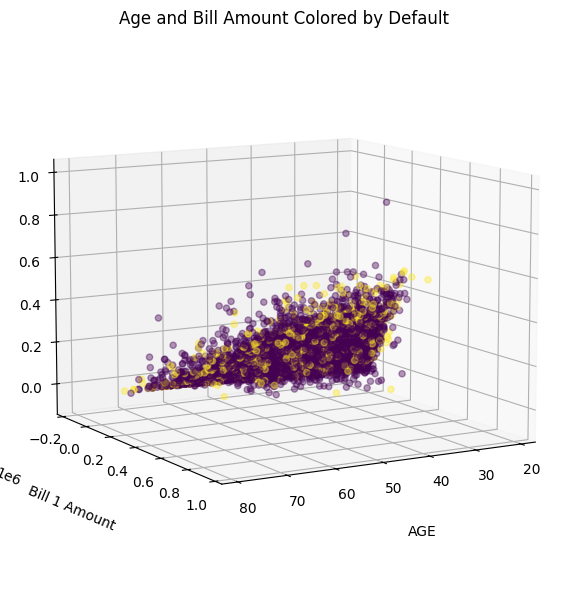

In [5]:
plt.figure(figsize = (6,6))
ax = plt.axes(projection = '3d')
ax.scatter3D(default['AGE'], default['BILL_AMT1'], default['BILL_AMT2'], c = default['default.payment.next.month'], alpha = 0.4)
ax.set_xlabel('AGE', labelpad = 20)
ax.set_ylabel('Bill 1 Amount', labelpad = 20)
ax.set_zlabel('Bill 2 Amount', labelpad = 20)
ax.view_init(10, 60)
plt.title('Age and Bill Amount Colored by Default')
plt.tight_layout();

In [6]:
px.scatter_3d(data_frame=default, x = 'AGE', y = 'BILL_AMT1', z = 'BILL_AMT2', color = 'default.payment.next.month')

### Reduce the dimensionality of the data to 3

The code below sets the features and target columns for our analysis as well as scaling the data using `StandardScaler`.

In [7]:
#feature & target
target = default['default.payment.next.month']
features = default.iloc[:,:-1]
#scale data
scaler=StandardScaler()
Scaled_data=scaler.fit_transform(features)

Next, it applies PCA with three components to the scaled data.

In [8]:
#pca to 3 dimensions
# PCA to reduce dimensions to 3
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(Scaled_data)

Finally, we plot the resuls of PCA in 3D using Matplotlib.

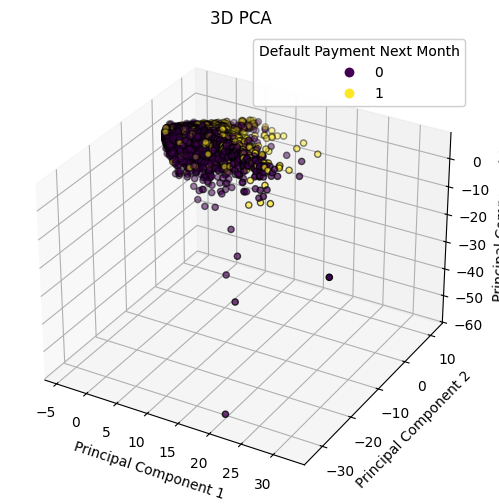

In [9]:
#plot in 3D with Matplotlib
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=target, cmap='viridis', edgecolor='k')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
plt.title('3D PCA')
legend1 = ax.legend(*scatter.legend_elements(), title='Default Payment Next Month')
ax.add_artist(legend1)
plt.show()

### Reduce the dimensionality of the data to 2

Applying PCA with two components to the scaled data.

In [10]:
#pca to 2 dimensions
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(Scaled_data)

Finally, we plot the resuls of PCA in 2D using Matplotlib.

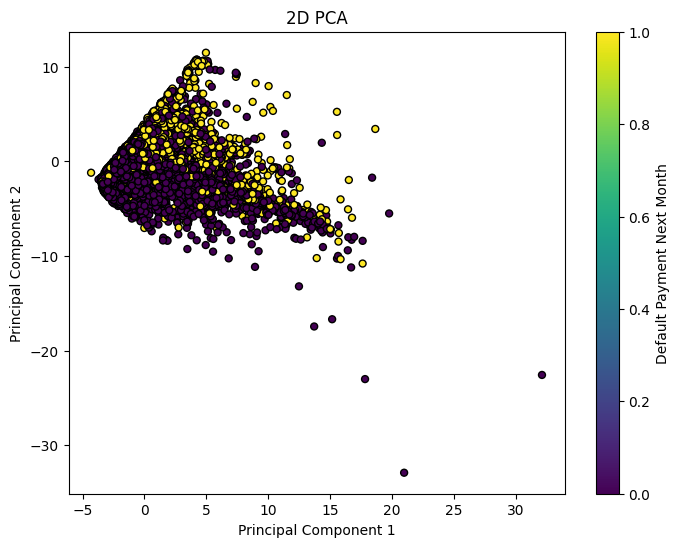

In [11]:
#plot in 2D with Matplotlib
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=target, cmap='viridis', edgecolor='k', s=25)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA')
plt.colorbar(label='Default Payment Next Month')
plt.show()

**The provided visualizations from the PCA analysis offer insights into the distribution of the data after dimensionality reduction. Here’s an analysis based on the visualizations:**

*2D PCA:*

- Separation of Groups: The 2D PCA scatterplot shows that the data points are not distinctly separated into clear groups based on the `default payment next month` feature. The points appear to be somewhat overlapping, with both default and non-default customers spread across the plot without clear boundaries.

- Data Representation: Despite the overlap, the 2D PCA does provide a more succinct representation of the dataset by condensing the information into two principal components. However, it seems that these two components alone may not capture enough of the variance to clearly distinguish between the two groups of interest.

*3D PCA:*
- Separation of Groups: Similarly, the 3D PCA scatterplot does not show a clear separation between groups. While there may be a slight distinction in some areas of the plot, the clusters of default vs. non-default customers are not distinctly partitioned.

- Data Representation: The third dimension adds more detail to the data representation, potentially capturing more variance and hence more information about the dataset. However, even with three principal components, there isn't a clear division between groups, suggesting that the patterns governing default payments are complex and may not be linearly separable.

*Conclusion:*
- PCA Findings: Both 2 and 3 principal components provide a condensed view of the dataset, but neither seems to clearly separate the default and non-default customers. This suggests that the default payment behavior is influenced by a complex combination of features that PCA, as a linear method, cannot easily untangle.

- Data Representation: While PCA reduces dimensionality and may help visualize trends and clusters to some extent, it does not always result in clear separability for classification purposes, especially when the underlying relationships in the data are non-linear or involve complex interactions among features.

To sum up, PCA has provided a more succinct data representation but has not achieved clear separation into groups based on the 'default payment next month' feature, indicating that the complexity of the data requires more sophisticated methods or additional feature engineering to improve class separability.

In [12]:
default.copy()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
2,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
3,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
4,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
5,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29996,220000.0,1,3,1,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29997,150000.0,1,3,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29998,30000.0,1,2,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1


In [13]:
df1 = default.copy()

In [14]:
df_scaled = (df1 - df1.mean()) / df1.std()

In [15]:
from scipy.linalg import svd

U, sigma, VT = svd(df_scaled, full_matrices=False)

In [16]:
import numpy as np
np.allclose(df_scaled.values, U @ np.diag(sigma) @ VT)

True

In [17]:
percent_variance_explained = sigma / sigma.sum()
cumulative_variance = np.cumsum(percent_variance_explained)

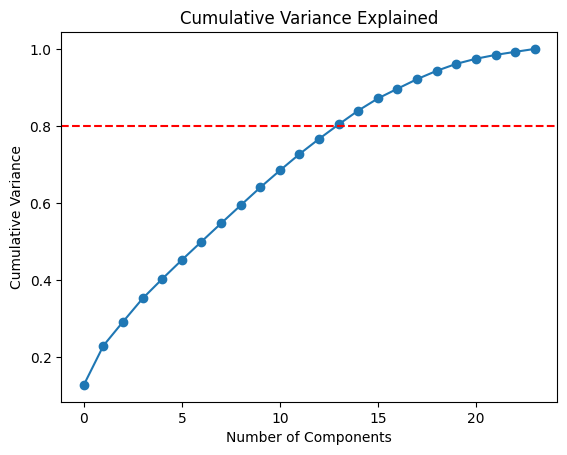

In [18]:
import matplotlib.pyplot as plt

plt.plot(cumulative_variance, marker='o')
plt.axhline(0.8, color='r', linestyle='--')
plt.title("Cumulative Variance Explained")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.show()

In [19]:
r = np.where(cumulative_variance >= 0.8)[0][0] + 1
print(f"Keep {r} components.")

Keep 14 components.


In [20]:
X_reduced = U[:, :r] @ np.diag(sigma[:r])

In [21]:
pca_df = pd.DataFrame(X_reduced, columns=[f'pca_{i}' for i in range(1, r+1)])

In [22]:
pca_df

,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10,pca_11,pca_12,pca_13,pca_14
0,-1.800943,-1.270372,0.590276,0.400274,-0.111690,-1.623439,-2.692784,-0.093171,0.524130,0.214024,-0.185968,0.080236,-2.290678,0.904513
1,-0.671417,-2.406229,-1.040722,0.357744,0.299730,-0.975021,-0.784850,-0.280614,0.095558,0.160046,0.114306,-0.161251,1.394150,0.120694
2,-0.858532,-0.969750,-0.470745,0.477480,0.953584,0.069041,0.276233,0.238143,-0.001802,0.152949,0.102576,-0.084103,0.077279,-0.538790
3,-0.210002,-0.706119,0.782267,-0.208423,1.068129,-0.199158,0.503662,-0.108682,-0.034603,-0.118077,-0.056227,-0.041242,-0.383047,0.648569
4,-0.860068,0.002982,1.041098,-2.245439,-0.464807,1.410860,0.627000,-0.552872,-0.253843,-0.608475,-0.287371,-1.104287,0.203664,-0.083222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,2.493641,0.815883,1.635643,-0.397772,0.044957,1.641110,-0.069632,0.343851,0.568620,-0.268937,-0.404584,-0.235120,-0.228741,0.431713
29996,-1.795090,0.020810,0.392398,-0.461553,-0.050590,1.992914,-0.050131,0.271705,-0.341535,0.112420,0.554274,-0.209557,1.190213,-0.679123
29997,0.465984,-3.609570,-0.500560,-0.616312,-1.906432,-0.186192,-2.421610,-0.017191,-0.131353,0.503985,0.888143,0.135018,-2.295386,-1.151771
29998,0.718814,0.383657,-0.323226,-3.033404,-0.631926,0.625607,-2.322651,1.299465,1.057337,-1.773371,-1.133461,4.373638,0.500722,0.964395


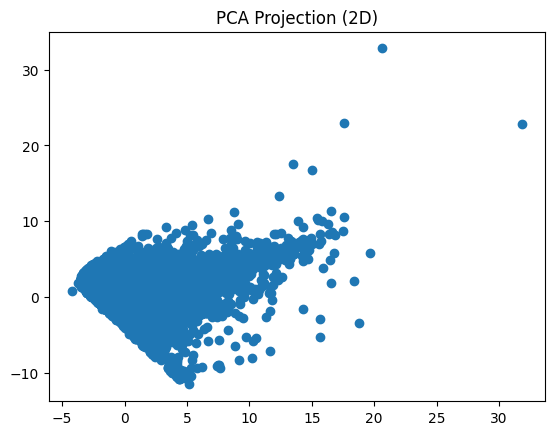

In [23]:
plt.scatter(pca_df["pca_1"], pca_df["pca_2"])
plt.title("PCA Projection (2D)")
plt.show()

In [24]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(pca_df)

1. Non-Linear Dimensionality Reduction (High Priority)
Rationale: Since PCA (linear) didn't separate the groups, the relationships are likely non-linear.
Workflow A: t-SNE

In [25]:
# t-SNE excels at preserving local structure
from sklearn.manifold import TSNE

# Multiple perplexity values to understand different scales
for perplexity in [5, 30, 50, 100]:
    tsne = TSNE(n_components=2, perplexity=perplexity, 
                random_state=42, max_iter=1000)
    X_tsne = tsne.fit_transform(Scaled_data)
    # Visualize with default status as color

In [ ]:
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE

# Run t-SNE for multiple perplexity values
for perplexity in [5, 30, 50, 100]:
    tsne = TSNE(n_components=2, perplexity=perplexity, 
                random_state=42, max_iter=1000)
    X_tsne = tsne.fit_transform(Scaled_data)

    plt.figure(figsize=(6, 5))
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=10, cmap='viridis')
    plt.title(f"t-SNE Projection (perplexity={perplexity})")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True)
    plt.show()

Why: t-SNE can reveal non-linear clusters that PCA misses. Different perplexity values show structure at different scales.
Workflow B: UMAP (Preferred for this use case)

In [28]:
import umap

# UMAP is faster than t-SNE and preserves both local and global structure
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, 
                    n_components=2, metric='euclidean')
X_umap = reducer.fit_transform(Scaled_data)

# Can also do supervised UMAP
reducer_supervised = umap.UMAP(n_neighbors=15, min_dist=0.1,
                               n_components=2)
X_umap_supervised = reducer_supervised.fit_transform(Scaled_data, y=target)

ModuleNotFoundError: No module named 'umap'

Why: UMAP often outperforms t-SNE, especially with labeled data (supervised UMAP).

2. Supervised Dimensionality Reduction (High Priority)
Rationale: You have labels (default/non-default), so use them!
Workflow C: Linear Discriminant Analysis (LDA)

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# LDA finds linear combinations that maximize class separation
lda = LinearDiscriminantAnalysis(n_components=1)  # Binary: max 1 component
X_lda = lda.fit_transform(Scaled_data, target)

# Examine feature weights to understand what drives defaults
lda_loadings = pd.DataFrame(
    lda.coef_.T,
    columns=['LD1'],
    index=features.columns
).sort_values('LD1', ascending=False)

Why: Explicitly optimizes for class separation. Feature weights tell you which variables matter most.

3. Clustering-First Approaches (Medium Priority)
Rationale: Maybe the data has natural customer segments that don't align perfectly with default status.
Workflow D: Hierarchical Clustering + Dendrogram

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Build dendrogram to understand natural groupings
linkage_matrix = linkage(Scaled_data, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30)

# Then apply hierarchical clustering
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
clusters = hc.fit_predict(Scaled_data)

# Analyze: What's the default rate in each cluster?
pd.crosstab(clusters, target, normalize='index')

Why: Reveals hierarchical structure. May find customer segments with varying default rates.
Workflow E: DBSCAN (Density-Based)

In [ ]:
from sklearn.cluster import DBSCAN

# On PCA-reduced data first (computational efficiency)
dbscan = DBSCAN(eps=0.5, min_samples=50)
clusters_db = dbscan.fit_predict(X_pca_3d)

# Analyze default rates by cluster including "noise" points

Why: Finds arbitrary-shaped clusters and identifies outliers (potentially high-risk customers).

4. Feature Engineering & Domain-Specific Insights (High Priority)
Rationale: Create interpretable features that capture payment behavior patterns.
Workflow F: Engineered Payment Behavior Features

In [ ]:
# Create new features that capture payment patterns
df_eng = default.copy()

# Payment trend (getting better or worse?)
df_eng['payment_trend'] = (df_eng['PAY_0'] - df_eng['PAY_6']) / 6

# Payment volatility
payment_cols = [f'PAY_{i}' for i in [0, 2, 3, 4, 5, 6]]
df_eng['payment_volatility'] = default[payment_cols].std(axis=1)

# Bill amount trend
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
df_eng['bill_trend'] = (default['BILL_AMT1'] - default['BILL_AMT6']) / 6

# Payment ratio (payment amount / bill amount)
df_eng['avg_payment_ratio'] = (
    default[[f'PAY_AMT{i}' for i in range(1, 7)]].sum(axis=1) /
    default[bill_cols].sum(axis=1).replace(0, 1)
)

# Maximum delay ever experienced
df_eng['max_payment_delay'] = default[payment_cols].max(axis=1)

# Then apply PCA/clustering to these engineered features

Why: Domain-relevant features often reveal patterns better than raw data.

5. Tree-Based Feature Importance (High Priority)
Rationale: Use ML models to identify which features distinguish defaulters.
Workflow G: Random Forest Feature Importance

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# Train RF to identify important features
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(Scaled_data, target)

# Get feature importance
importance_df = pd.DataFrame({
    'feature': features.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# Focus PCA/clustering on top N features only
top_features = importance_df.head(10)['feature'].values
X_top = features[top_features]
# Re-run PCA/clustering on these features

Why: Reduces noise by focusing on predictive features.

6. Multi-Step Workflow (Comprehensive Approach)
Workflow H: Combined Strategy

In [ ]:
# Step 1: Feature selection
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(f_classif, k=12)
X_selected = selector.fit_transform(Scaled_data, target)

# Step 2: Apply supervised UMAP
umap_sup = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3)
X_umap = umap_sup.fit_transform(X_selected, y=target)

# Step 3: Cluster in UMAP space
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=5, covariance_type='full')
clusters = gmm.fit_predict(X_umap)

# Step 4: Profile each cluster
for cluster_id in range(5):
    mask = clusters == cluster_id
    print(f"\n=== Cluster {cluster_id} ===")
    print(f"Size: {mask.sum()}")
    print(f"Default rate: {target[mask].mean():.2%}")
    print("Average characteristics:")
    print(features[mask].mean())

7. Anomaly Detection Approach (Alternative Angle)
Workflow I: Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest

# Find anomalies (unusual customers)
iso_forest = IsolationForest(contamination=0.1, random_state=42)
anomalies = iso_forest.fit_predict(Scaled_data)

# Compare default rates: normal vs anomalous
print(f"Default rate (normal): {target[anomalies == 1].mean():.2%}")
print(f"Default rate (anomalies): {target[anomalies == -1].mean():.2%}")

Why: High-risk customers might be anomalies rather than a distinct cluster.


Recommended Prioritized Workflow
Phase 1: Quick Wins
LDA (Workflow C) - Supervised, interpretable, fast
Engineered features (Workflow F) - Domain insights
Feature importance (Workflow G) - Identify what matters
Phase 2: Deep Exploration
Supervised UMAP (Workflow B) - Best non-linear technique
Combined approach (Workflow H) - Comprehensive pipeline
Phase 3: Alternative Perspectives
Hierarchical clustering (Workflow D) - Customer segmentation
Anomaly detection (Workflow I) - Risk profiling